## The Mass Diffusion equation

We consider the following steady-state mass diffusion in a 2D material. The governing PDE is 
$$
\nabla( D(x,y) \nabla C(x,y)) = 0, \quad x\in\Omega
$$  
where $D$ is the diffusivity field and $C$ is the concentration field.
### (1.1) Neural Operator learning problem

The problem is defined in $\Omega=[0,1]^2$ with the following boundary conditions:
- **Left wall** ($x=0$): $C = 1$ (high concentration inflow)
- **Right wall** ($x=1$): $C = 0$ (zero concentration outflow)
- **Top/bottom walls**: zero normal flux (Neumann, natural BC)

We are interested in learning the mapping from the diffusivity field $D(x,y)$ to the concentration field $C(x,y)$, i.e.,
$$
\mathcal{G}: D(x,y) \rightarrow C(x,y)
$$

## (2) The Physics-informed DeepOnet

In [7]:
import sys 
sys.path.append("../..") 
import numpy as np
import h5py
import torch 
import matplotlib.pyplot as plt
#
def setup_seed(seed):
     torch.manual_seed(seed)
     torch.cuda.manual_seed_all(seed)
     np.random.seed(seed)
     torch.backends.cudnn.deterministic = True
# Set randon seed
random_seed = 1234
setup_seed(random_seed)
if torch.cuda.is_available():
    device = 'cuda:0'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
    
dtype = torch.float32
problem_name = 'massDiffusion_2d'
tag = 'diff'
######################################
# Load Mass diffusion dataset (D=1 uniform)
######################################
data_train = h5py.File('../../Problems/massDiffusion_2d/diff_train.mat', 'r')
data_test  = h5py.File('../../Problems/massDiffusion_2d/diff_test_in.mat', 'r')
print(data_train.keys())
print(data_test.keys())
res = 29
######################################
from Utils.utils import *
n_train, n_test = 1000, 200
def get_data(data, ndata, dtype, n0=0):
    # coeff stored as actual D values (1.0 for uniform D=1)
    a = np2tensor(np.array(data["coeff"][...,n0:n0+ndata]).T, dtype)
    # sol_fdm: FDM solution of the diffusion problem
    u = np2tensor(np.array(data["sol_fdm"][...,n0:n0+ndata]).T, dtype)
    #
    X, Y = np.array(data['X']).T, np.array(data['Y']).T
    mesh  = np2tensor(np.vstack([X.ravel(), Y.ravel()]).T, dtype)
    gridx = mesh.reshape(-1, 2)
    #
    x = gridx.repeat((ndata, 1, 1))
    a = a.reshape(ndata, -1, 1)
    u = u.reshape(ndata, -1, 1)
    
    return a, u, x, gridx
#
a_train, u_train, x_train, grid_train = get_data(data_train, n_train, dtype)
a_test,  u_test,  x_test,  grid_test  = get_data(data_test,  n_test,  dtype)
#
print('The shape of x_train:', x_train.shape)
print('The shape of a_train:', a_train.shape)
print('The shape of u_train:', u_train.shape)
print('The shape of grid_train:', grid_train.shape)
print('The shape of x_test:', x_test.shape)
print('The shape of a_test:', a_test.shape)
print('The shape of u_test:', u_test.shape)
print('The shape of grid_test:', grid_test.shape)
######################################
# Generate mesh grids for calculating gradients
######################################
from Utils.GenPoints import Point2D
pointGen = Point2D(x_lb=[0., 0.], x_ub=[1.,1.], dataType=dtype, random_seed=random_seed)
#
N_mesh = 29
x_mesh = pointGen.inner_point(N_mesh, method='mesh')
print('x_mesh shape:', x_mesh.shape)

<KeysViewHDF5 ['X', 'Y', 'coeff', 'sol_fdm']>
<KeysViewHDF5 ['X', 'Y', 'coeff', 'sol_fdm']>
The shape of x_train: torch.Size([1000, 841, 2])
The shape of a_train: torch.Size([1000, 841, 1])
The shape of u_train: torch.Size([1000, 841, 1])
The shape of grid_train: torch.Size([841, 2])
The shape of x_test: torch.Size([200, 841, 2])
The shape of a_test: torch.Size([200, 841, 1])
The shape of u_test: torch.Size([200, 841, 1])
The shape of grid_test: torch.Size([841, 2])
x_mesh shape: torch.Size([841, 2])


### (3.2) Define the loss class and train the model 

In [8]:
###############################
# Define Loss Class
###############################
from Utils.Grad import *
import torch.nn as nn
from torch.autograd import grad, Variable

########################################
class fun_a(object):

    def __init__(self, res):
        super(fun_a, self).__init__()
        self.res = res
        self.delta = 1./(res-1)

    def __call__(self, x, a):
        a = a.squeeze(-1)
        x_loc = torch.floor(x[...,0] / self.delta + 0.5).int()
        y_loc = torch.floor(x[...,1] / self.delta + 0.5).int()
        loc = y_loc * self.res + x_loc
        #
        img = a[torch.arange(a.size(0)).unsqueeze(1), loc]
        
        return img.unsqueeze(-1)

###############################
class mollifier(object):
    # Lifting function that builds mass diffusion BCs into the network output:
    #   C = u_nn * x*(1-x)*sin(pi*y)  +  (1-x)
    # At x=0: C = 0 + 1 = 1  (inflow, high concentration)
    # At x=1: C = 0 + 0 = 0  (outflow, zero concentration)
    # The sin(pi*y) factor smoothly suppresses the correction at y=0 and y=1,
    # leaving C = (1-x) there — the linear profile consistent with zero normal flux.
    def __call__(self, u, x):
        xx, yy = x[...,0:1], x[...,1:2]
        u = u * xx * (1 - xx) * torch.sin(np.pi * yy) + (1 - xx)

        return u
        
################################
class LossClass(object):

    def __init__(self, solver):
        super(LossClass, self).__init__()
        self.solver = solver
        self.dtype = solver.dtype
        self.device = solver.device
        self.fun_a = fun_a(res=res)
        self.model_u = solver.model_dict['u']
        self.mollifier = mollifier()
        #
        self.deltax = 1/(N_mesh-1)
        self.deltay = 1/(N_mesh-1)

    def Loss_pde(self, a_batch, w_pde):
        '''PDE loss for steady-state mass diffusion: div(D * grad(C)) = 0
        '''
        n_batch = a_batch.shape[0]
        if w_pde>0.:
            a = self.fun_a(x_mesh, a_batch)
            x = Variable(x_mesh.repeat(n_batch, 1, 1).to(self.device), requires_grad=True)
            u = self.model_u(x, a_batch)
            u = self.mollifier(u, x).reshape(-1, N_mesh, N_mesh, 1)
            a = a.reshape(-1, N_mesh, N_mesh, 1)
            dudx, dudy = FDM_2d(u, self.deltax, self.deltay)
            adux = a[:,1:-1,1:-1,0:1] * dudx
            aduy = a[:,1:-1,1:-1,0:1] * dudy
            dauxdx, _ = FDM_2d(adux, self.deltax, self.deltay)
            _, dauydy = FDM_2d(aduy, self.deltax, self.deltay)
            #############################################
            # Mass diffusion: div(D*grad(C)) = 0  →  dauxdx + dauydy = 0
            left = (dauxdx + dauydy).reshape(n_batch, -1)
            right = torch.zeros_like(left)

            return self.solver.getLoss(left, right)
        else:
            return torch.tensor(0.)

    def Loss_data(self, x, a, u, w_data):
        return torch.tensor(0.)

    def Error(self, x, a, u):
        u_pred = self.model_u(x, a)
        u_pred = self.mollifier(u_pred, x)
            
        return self.solver.getError(u_pred, u)

######################################
# Steups of the model
######################################
from Solvers.PIDeepONet import PIDeepONet
solver = PIDeepONet.Solver(device=device, dtype=dtype)
netType = 'DeepONetBatch'

####################################### The BranchNet
from Networks.CNNet import CNNet2d
class BranchNet(nn.Module):
    def __init__(self, conv_arch:list, fc_arch:list, 
                 nx_size:int, ny_size:int, dtype=None):
        super(BranchNet, self).__init__()
        self.nx_size, self.ny_size = nx_size, ny_size
        self.conv = CNNet2d(conv_arch=conv_arch, fc_arch=fc_arch,
                            activation_conv='SiLU', activation_fc='SiLU', 
                            kernel_size=(3,3), stride=2, dtype=dtype)
        
    def forward(self, x):
        x = x.reshape(-1, self.ny_size, self.nx_size).unsqueeze(1)
        x = self.conv(x)
        
        return x
#
conv_arch = [1, 64, 64, 64]
fc_arch = [64*2*2, 128, 128, 128]
branchNet = BranchNet(conv_arch, fc_arch, nx_size=res, ny_size=res, dtype=dtype)

###################################### The u model (DeepONet)
layers_branch, activation_branch = [branchNet, fc_arch[-1]], 'SiLU'
layers_trunk, activation_trunk = [2, 128, 128, 128, 128], 'ReLU'
model_u = solver.getModel(layers_branch, layers_trunk, activation_branch, activation_trunk, 
                          multi_ouput_strategy=None, num_output=1, netType=netType)
##################
total_trainable_params = sum(p.numel() for p in model_u.parameters() if p.requires_grad)
print(f'{total_trainable_params:,} training parameters.')

190,337 training parameters.


### (2.3) training and make prediction

#### (2.3.1) train the model

In [9]:
model_dict = {'u':model_u}
solver.train_setup(model_dict, lr=1e-3, optimizer='Adam', scheduler_type='StepLR',
                   gamma=0.6, step_size=200)
solver.train(LossClass, a_train, u_train, x_train, a_test, u_test, x_test, 
             w_data=0., w_pde=1., batch_size=50, epochs=1000, epoch_show=50,
             **{'save_path':f'saved_models/PI{netType}_{tag}/'})

  5%|████▌                                                                                     | 50/1000 [00:11<03:39,  4.34it/s]

Epoch:50 Time:11.2364, loss:0.5525, loss_pde:0.5525, loss_data:0.0000
                l2_test:0.0472, lr:0.001


 10%|████████▉                                                                                | 100/1000 [00:21<03:02,  4.93it/s]

Epoch:100 Time:21.7649, loss:0.3418, loss_pde:0.3418, loss_data:0.0000
                l2_test:0.0465, lr:0.001


 15%|█████████████▎                                                                           | 150/1000 [00:33<03:31,  4.02it/s]

...

Epoch:900 Time:200.6810, loss:0.0615, loss_pde:0.0615, loss_data:0.0000
                l2_test:0.0463, lr:0.00012959999999999998


 95%|████████████████████████████████████████████████████████████████████████████████████▌    | 950/1000 [03:32<00:10,  4.58it/s]

Epoch:950 Time:212.1711, loss:0.0392, loss_pde:0.0392, loss_data:0.0000
                l2_test:0.0464, lr:0.00012959999999999998


100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:43<00:00,  4.46it/s]

Epoch:1000 Time:223.9787, loss:0.0440, loss_pde:0.0440, loss_data:0.0000
                l2_test:0.0464, lr:7.775999999999999e-05
The total training time is 223.9875


### (3.3) load saved model and make prediction

The shape of a_test: torch.Size([200, 841, 1])
The shape of u_test: torch.Size([200, 841, 1]) u_pred shape torch.Size([200, 841, 1])
The test l2 error (avg): tensor(0.0442)


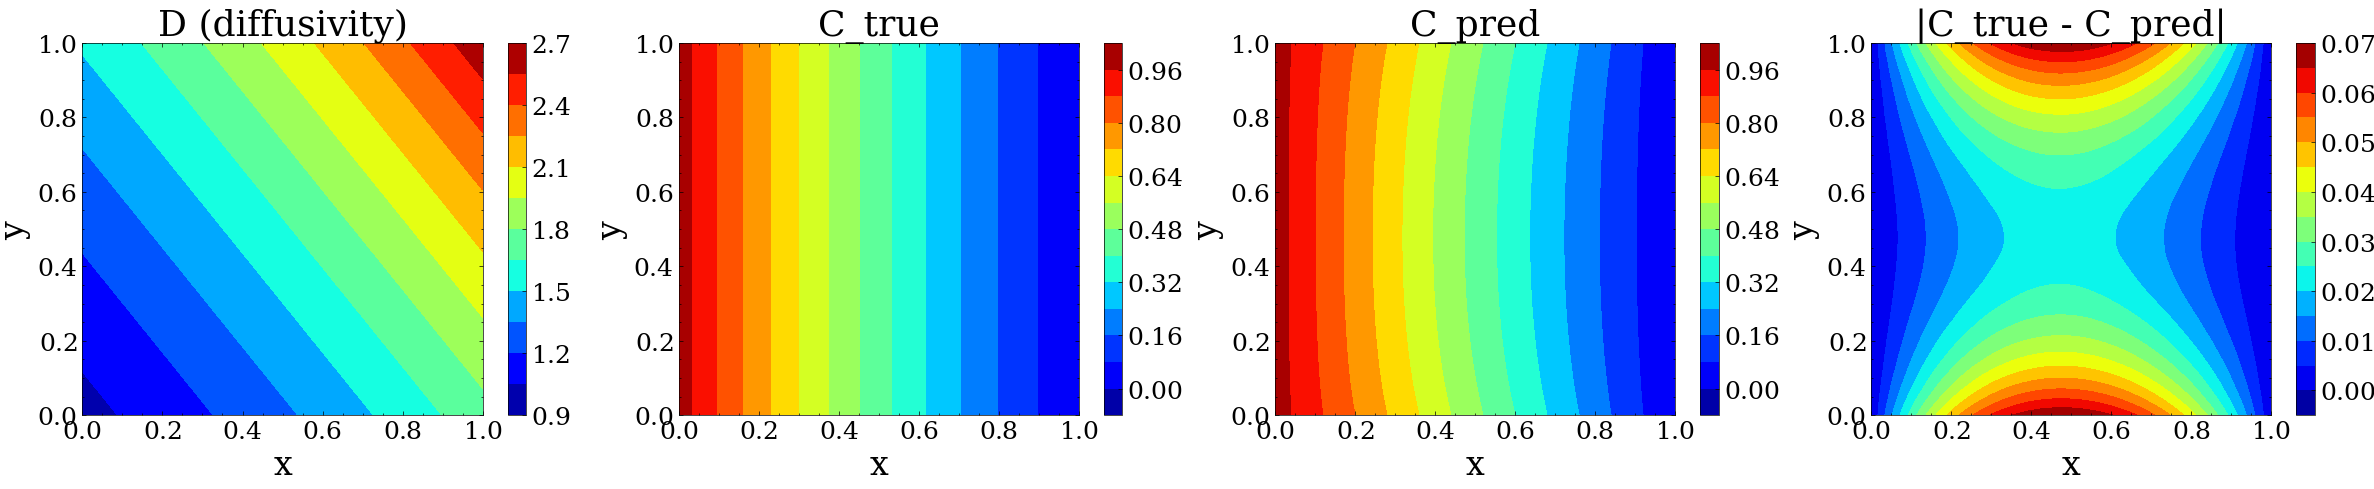

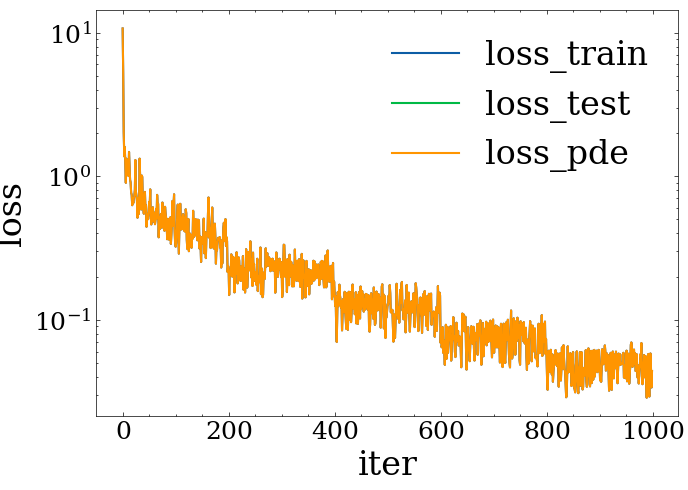

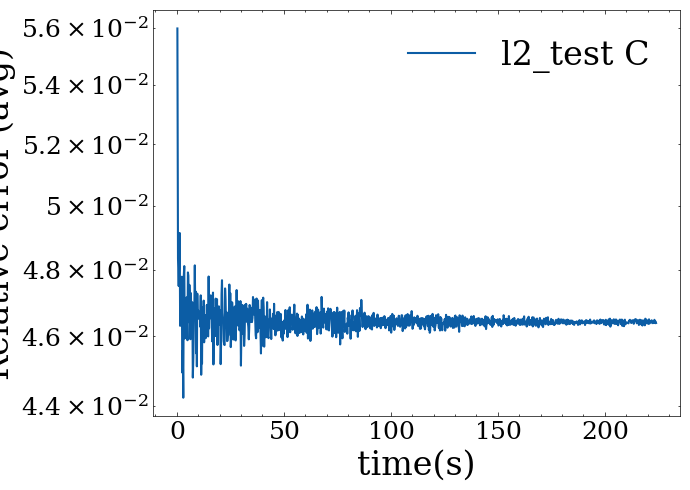

In [10]:
# #######################################
# # Load the trained model
# #######################################
from Solvers.PIDeepONet import PIDeepONet
from torch.autograd import Variable
solver = PIDeepONet.Solver(device=device, dtype=dtype)
model_trained = solver.loadModel(path=f'saved_models/PI{netType}_{tag}/', 
                                 name=f'model_pideeponet_besterror')

#########################################
x_var = Variable(x_test.to(device), requires_grad=True)
a_var = a_test.to(device)
u_pred = model_trained['u'](x_var, a_var)
u_pred = mollifier()(u_pred, x_var).detach().cpu()
#
print('The shape of a_test:', a_test.shape)
print('The shape of u_test:', u_test.shape, 'u_pred shape', u_pred.shape)
print('The test l2 error (avg):', solver.getError(u_pred, u_test))
inx = 0
# ########################################
from Utils.PlotFigure import Plot
Plot.show_2d_list([grid_test]*4, 
                  [a_test[inx], u_test[inx], u_pred[inx], torch.abs(u_test[inx]-u_pred[inx])], 
                  ['D (diffusivity)', 'C_true', 'C_pred', '|C_true - C_pred|'], lb=0.)
#############################################
# show loss
loss_saved = solver.loadLoss(path=f'saved_models/PI{netType}_{tag}/', name='loss_pideeponet')
Plot.show_loss([loss_saved['loss_train'], loss_saved['loss_test'], loss_saved['loss_pde']], 
               ['loss_train', 'loss_test', 'loss_pde'])
Plot.show_error([loss_saved['time']], [loss_saved['error']], ['l2_test C'])